<a href="https://colab.research.google.com/github/ushak1984/cybersecurity-threat-detection-ml/blob/main/01_data_quality_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cybersecurity Data Quality and Preprocessing Review

**Author:** Usha Priya Krishnasamy  
**Project Type:** Exploratory data quality review and preprocessing  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15  

## Project Overview

This notebook reviews three cybersecurity datasets used for network threat detection, attack classification, and anomaly detection.

The purpose of this notebook is to check whether each dataset is suitable for later machine learning work. The review focuses on dataset structure, missing values, duplicate records, categorical features, target distributions, class imbalance, and basic consistency checks.

This notebook is part of a larger capstone project on detecting cybersecurity threats using supervised classification and unsupervised anomaly detection.

## Note

This version keeps the saved code outputs and visualizations from the original run so the notebook can be reviewed on GitHub without rerunning the datasets.

The raw datasets are not included in this repository. The analysis was developed using public cybersecurity datasets.

## Storytelling Plan

### BETH Honeypot Dataset

**Who:** Security analysts, cybersecurity researchers, and data science reviewers interested in host-level threat behavior.

**What:** The analysis reviews process, host, user, event, and attack-label patterns from honeypot logs.

**How:** Data quality checks, label distribution review, categorical encoding, and visual analysis are used to identify suspicious and malicious activity patterns.

### Cybersecurity Attacks Dataset

**Who:** Data science reviewers and cybersecurity learners exploring attack-type classification and security event data.

**What:** The analysis reviews attack types, severity levels, protocol information, alert fields, and missing-value patterns.

**How:** Summary statistics, missing-value checks, categorical review, and attack/severity visualizations are used to assess whether this dataset is useful for modeling.

### UNSW-NB15 Dataset

**Who:** Security operations teams, intrusion detection researchers, and machine learning reviewers.

**What:** The analysis reviews network-flow features and binary attack labels for intrusion detection modeling.

**How:** Duplicate checks, missing-value review, categorical encoding, outlier inspection, and class-distribution analysis are used to prepare the data for classification.

# 3. Dataset 1 : BETH
https://www.kaggle.com/datasets/katehighnam/beth-dataset

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
## 3(a)  Install  kagglehub
#!pip install kagglehub
import kagglehub
print("Kagglehub version:", kagglehub.__version__)
#!pip install --upgrade kagglehub

Kagglehub version: 1.0.2


In [3]:
## 3(b) Download the dataset from kaggle
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")

print("Path to dataset files:", beth_dataset_path)

100%|██████████| 39.8M/39.8M [00:03<00:00, 13.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/katehighnam/beth-dataset/versions/3


In [4]:
import os

# List all files in the dataset directory
print(os.listdir(beth_dataset_path))

['labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_training_data.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_validation_data.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_testing_data.csv', 'labelled_2021may-ubuntu.csv']


In [5]:
# List of kernel log files- Merge and split the training,test and validation to balance classes ( evil=1 malicious activity)across the datasets
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]

dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)

# Verify
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)

# Verify the sizes
print("\nTraining set size:", len(df_beth))
print("Validation set size:", len(df_val))
print("Test set size:", len(df_test))
same_columns = (
    (df_beth.columns == df_test.columns).all() and
    (df_beth.columns == df_val.columns).all()
)

print("All DataFrames have the same columns in the same order:", same_columns)
# Check EVIL distribution in each split
print("\nEVIL Distribution in Training set:")
print(df_beth['evil'].value_counts())
print("\nEVIL Distribution in Validation set:")
print(df_val['evil'].value_counts())
print("\nEVIL Distribution in Test set:")
print(df_test['evil'].value_counts())

# Save the split datasets (optional)
df_beth.to_csv('split_beth_train.csv', index=False)
df_val.to_csv('split_beth_val.csv', index=False)
df_test.to_csv('split_beth_test.csv', index=False)
print("\nSplit datasets saved as 'split_beth_train.csv', 'split_beth_val.csv', and 'split_beth_test.csv'")



Training set size: 684646
Validation set size: 228216
Test set size: 228216
All DataFrames have the same columns in the same order: True

EVIL Distribution in Training set:
evil
0    589587
1     95059
Name: count, dtype: int64

EVIL Distribution in Validation set:
evil
0    196529
1     31687
Name: count, dtype: int64

EVIL Distribution in Test set:
evil
0    196530
1     31686
Name: count, dtype: int64

Split datasets saved as 'split_beth_train.csv', 'split_beth_val.csv', and 'split_beth_test.csv'


In [6]:
 # 3(b) Summarize the datasets
## Display the first 5 records in chosen dataset
df_beth.head()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,processName,hostName,eventId,eventName,stackAddresses,argsNum,returnValue,args,sus,evil
1060840,472.442379,7555,7555,7548,1001,4026531840,tsm,ip-10-100-1-217,3,close,[],1,0,"[{'name': 'fd', 'type': 'int', 'value': 80}]",1,1
608882,914.843280,7282,7282,187,0,4026532217,systemd-udevd,ubuntu,257,openat,[140085331927078],4,15,"[{'name': 'dirfd', 'type': 'int', 'value': 6},...",0,0
56548,2886.683328,7369,7369,1317,0,4026531840,ps,ip-10-100-1-120,3,close,[],1,0,"[{'name': 'fd', 'type': 'int', 'value': 9}]",0,0
1071941,479.252498,7555,7555,7548,1001,4026531840,tsm,ip-10-100-1-217,42,connect,[],3,-114,"[{'name': 'sockfd', 'type': 'int', 'value': 44...",1,1
695524,550.777799,7318,7318,7099,0,4026531840,sshd,ip-10-100-1-57,1005,security_file_open,"[139787436179115, 8313483762523399788]",4,0,"[{'name': 'pathname', 'type': 'const char*', '...",0,0


In [7]:
## Find the dataset size
print("Dimension (No.of Rows, No.of Columns) of the Dataset: ",df_beth.shape)

Dimension (No.of Rows, No.of Columns) of the Dataset:  (684646, 16)


In [8]:
## Find the datatype of each feature in the dataset
df_beth.dtypes

,0
timestamp,float64
processId,int64
threadId,int64
parentProcessId,int64
userId,int64
mountNamespace,int64
processName,object
hostName,object
eventId,int64
eventName,object


In [9]:
## List the numeric and categorical columns in the dataset
numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print("Numeric columns in the BETH dataseta are\n")
print(numeric_columns_beth.tolist())

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print("\n\nCategorical_columns in the BETH dataseta are\n")
print(categorical_columns_beth.tolist())

Numeric columns in the BETH dataseta are

['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'mountNamespace', 'eventId', 'argsNum', 'returnValue', 'sus', 'evil']


Categorical_columns in the BETH dataseta are

['processName', 'hostName', 'eventName', 'stackAddresses', 'args']


In [10]:
print(df_beth['sus'].unique())
print(df_beth['sus'].head(10))

[1 0]
1060840    1
608882     0
56548      0
1071941    1
695524     0
689889     0
28151      0
390589     0
870686     0
880429     0
Name: sus, dtype: int64


In [11]:
## Dataset Information: Dimension, Column Names & its count, data types
df_beth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 684646 entries, 1060840 to 443202
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   timestamp        684646 non-null  float64
 1   processId        684646 non-null  int64  
 2   threadId         684646 non-null  int64  
 3   parentProcessId  684646 non-null  int64  
 4   userId           684646 non-null  int64  
 5   mountNamespace   684646 non-null  int64  
 6   processName      684646 non-null  object 
 7   hostName         684646 non-null  object 
 8   eventId          684646 non-null  int64  
 9   eventName        684646 non-null  object 
 10  stackAddresses   684646 non-null  object 
 11  argsNum          684646 non-null  int64  
 12  returnValue      684646 non-null  int64  
 13  args             684646 non-null  object 
 14  sus              684646 non-null  int64  
 15  evil             684646 non-null  int64  
dtypes: float64(1), int64(10), object(5)
m

In [12]:
## Dataset Description: Statistical summary for numerical columns of the dataset
df_beth.describe()

,timestamp,processId,threadId,parentProcessId,userId,mountNamespace,eventId,argsNum,returnValue,sus,evil
count,684646.000000,684646.000000,684646.000000,684646.000000,684646.000000,6.846460e+05,684646.000000,684646.000000,684646.000000,684646.000000,684646.000000
mean,1367.752468,6907.282533,6911.381515,2468.978485,143.807685,4.026532e+09,237.077479,2.670875,2.969952,0.152216,0.138844
std,1154.370791,1819.847219,1810.264938,2863.819822,350.188460,1.726619e+02,354.629356,1.250361,320.751188,0.359230,0.345784
min,124.439751,1.000000,1.000000,0.000000,0.000000,4.026532e+09,2.000000,0.000000,-115.000000,0.000000,0.000000
25%,461.295371,7301.000000,7301.000000,187.000000,0.000000,4.026532e+09,4.000000,1.000000,0.000000,0.000000,0.000000
50%,903.362543,7366.000000,7366.000000,1385.000000,0.000000,4.026532e+09,42.000000,3.000000,0.000000,0.000000,0.000000
75%,2327.306506,7461.000000,7461.000000,4489.000000,0.000000,4.026532e+09,257.000000,4.000000,0.000000,0.000000,0.000000
max,3954.587643,8619.000000,8619.000000,7672.000000,1001.000000,4.026532e+09,1010.000000,5.000000,32768.000000,1.000000,1.000000


In [13]:
 ## List the evil and suspicious labels
# Label Distribution (EVIL and SUS)
print("\nLabel Distribution:")
print(df_beth['evil'].value_counts())
print("\nSUS Distribution:")
print(df_beth['sus'].value_counts())


Label Distribution:
evil
0    589587
1     95059
Name: count, dtype: int64

SUS Distribution:
sus
0    580432
1    104214
Name: count, dtype: int64


In [14]:
# 3 (c) Are there any duplicate rows?

duplicate_rows = df_beth[df_beth.duplicated()]
print(f"Duplicate rows: {len(duplicate_rows)}")
#duplicate_rows

Duplicate rows: 0


In [15]:
# 3(d) Are there any duplicate values in a given column (when this would be inappropriate?)
for col in df_beth.columns:
    if df_beth[col].duplicated().sum() > 0:
        print(f"Column {col} has duplicate values.")

Column timestamp has duplicate values.
Column processId has duplicate values.
Column threadId has duplicate values.
Column parentProcessId has duplicate values.
Column userId has duplicate values.
Column mountNamespace has duplicate values.
Column processName has duplicate values.
Column hostName has duplicate values.
Column eventId has duplicate values.
Column eventName has duplicate values.
Column stackAddresses has duplicate values.
Column argsNum has duplicate values.
Column returnValue has duplicate values.
Column args has duplicate values.
Column sus has duplicate values.
Column evil has duplicate values.


In [16]:
 # 3(e) What are the mean, median, and mode of each column?

mean_values = df_beth.mean(numeric_only=True)
print("Mean values:\n", mean_values)

median_values = df_beth.median(numeric_only=True)
print("\nMedian values:\n", median_values)

# Mode (can have multiple values per column)
mode_values = df_beth.mode(numeric_only=True).iloc[0]
print("\nMode values:\n", mode_values)

Mean values:
 timestamp          1.367752e+03
processId          6.907283e+03
threadId           6.911382e+03
parentProcessId    2.468978e+03
userId             1.438077e+02
mountNamespace     4.026532e+09
eventId            2.370775e+02
argsNum            2.670875e+00
returnValue        2.969952e+00
sus                1.522159e-01
evil               1.388440e-01
dtype: float64

Median values:
 timestamp          9.033625e+02
processId          7.366000e+03
threadId           7.366000e+03
parentProcessId    1.385000e+03
userId             0.000000e+00
mountNamespace     4.026532e+09
eventId            4.200000e+01
argsNum            3.000000e+00
returnValue        0.000000e+00
sus                0.000000e+00
evil               0.000000e+00
dtype: float64

Mode values:
 timestamp          1.329349e+02
processId          7.555000e+03
threadId           7.555000e+03
parentProcessId    1.870000e+02
userId             0.000000e+00
mountNamespace     4.026532e+09
eventId            3.000000e

In [17]:
# 3(f). Are there any missing or null values?
# Check for missing or null values
missing_values = df_beth.isna().sum().sort_values(ascending=False)
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64


In [18]:
# 3(g) Do you want to fill in the missing value with a mean value? A value of your choice? Remove that row?
numeric_cols_beth = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
                'mountNamespace', 'eventId', 'argsNum', 'returnValue', 'sus', 'evil']
for col in numeric_cols_beth:
    if df_beth[col].isna().sum() > 0:
        df_beth[col].fillna(df_beth[col].median(), inplace=True)

# For categorical columns, fill with mode or 'Unknown'
categorical_cols_beth = ['processName', 'hostName', 'eventName', 'args']  # Adjust based on actual columns
for col in categorical_cols_beth:
    if col in df_beth.columns and df_beth[col].isna().sum() > 0:
        df_beth[col].fillna(df_beth[col].mode()[0], inplace=True)  # Use mode
        # Alternatively: df_beth[col].fillna('Unknown', inplace=True)

# If missing values are critical or extensive, consider dropping rows
# df_beth.dropna(subset=['eventName', 'args'], inplace=True)

# Verify missing values after handling
print("Missing values after handling:\n", df_beth.isna().sum())

Missing values after handling:
 timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64


In [19]:
 # Check for negative or zero values in IDs
print("Negative or zero processId:", len(df_beth[df_beth['processId'] <= 0]))
print("Negative or zero threadId:", len(df_beth[df_beth['threadId'] <= 0]))
print("Negative or zero parentProcessId:", len(df_beth[df_beth['parentProcessId'] <= 0]))
print("Negative userId:", len(df_beth[df_beth['userId'] < 0]))

# Check for negative timestamps
print("Negative timestamps:", len(df_beth[df_beth['timestamp'] < 0]))

# Check for non-binary sus or evil values
print("Non-binary sus values:", len(df_beth[~df_beth['sus'].isin([0, 1])]))
print("Non-binary evil values:", len(df_beth[~df_beth['evil'].isin([0, 1])]))

# Check for outliers in returnValue (e.g., beyond reasonable system call return values)
print("Extreme returnValue (>1e6 or <-1e6):",
      len(df_beth[(df_beth['returnValue'] > 1e6) | (df_beth['returnValue'] < -1e6)]))

Negative or zero processId: 0
Negative or zero threadId: 0
Negative or zero parentProcessId: 13843
Negative userId: 0
Negative timestamps: 0
Non-binary sus values: 0
Non-binary evil values: 0
Extreme returnValue (>1e6 or <-1e6): 0


In [20]:
# 3(i). Encode any categorical variables
# Identify categorical columns
categorical_cols_beth_encode = ['processName', 'hostName', 'eventName']  # Adjust based on actual columns

# Apply one-hot encoding
df_beth_encoded = pd.get_dummies(df_beth, columns=categorical_cols_beth_encode, prefix=categorical_cols_beth_encode)

# If 'args' is a complex string (e.g., JSON or command-line arguments), consider feature extraction
# Example: Extract length of args or specific keywords (advanced preprocessing)
df_beth_encoded['args_length'] = df_beth['args'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

print("Encoded dataset shape:", df_beth_encoded.shape)
print(df_beth_encoded.head())

Encoded dataset shape: (684646, 269)
           timestamp  processId  threadId  parentProcessId  userId  \
1060840   472.442379       7555      7555             7548    1001   
608882    914.843280       7282      7282              187       0   
56548    2886.683328       7369      7369             1317       0   
1071941   479.252498       7555      7555             7548    1001   
695524    550.777799       7318      7318             7099       0   

         mountNamespace  eventId                          stackAddresses  \
1060840      4026531840        3                                      []   
608882       4026532217      257                       [140085331927078]   
56548        4026531840        3                                      []   
1071941      4026531840       42                                      []   
695524       4026531840     1005  [139787436179115, 8313483762523399788]   

         argsNum  returnValue  ... eventName_setregid  eventName_setreuid  \
1060840 

In [21]:
# Anomaly and Malicious Processes - Identification and visualisation
df_both = df_beth[(df_beth['sus'] == 1) & (df_beth['evil'] == 1)]
uniqueC=df_both['processName'].unique()
print(uniqueC)

# Display the results

print(df_both['processName'].value_counts().head())

['tsm' 'nohup' 'lscpu' 'crontab' '(sd-executor)' 'sshd' 'systemctl'
 'passwd' 'w' 'cut' '(ystemctl)' 'stat' 'thread-pool-140' 'rm' 'grep'
 'sleep' 'cat' 'wc' 'bash' 'id' 'whoami' 'date' 'mkdir' 'sh' 'free' 'mv'
 'who' 'tar' 'base64' 'uname' 'top' 'ls' 'awk' 'dirname' 'mktemp'
 'readlink' 'find' 'sftp-server' 'thread-pool-109' 'which' 'thread-pool-3'
 'thread-pool-90' 'head' 'thread-pool-18' 'thread-pool-141'
 'thread-pool-138' '(sd-pam)' 'thread-pool-73' 'sort' 'bc'
 'thread-pool-116' 'thread-pool-94' 'thread-pool-122' 'thread-pool-70'
 'thread-pool-74' 'thread-pool-54' 'thread-pool-146' 'thread-pool-35'
 'thread-pool-57' 'thread-pool-33' 'thread-pool-93' 'tr' 'thread-pool-63'
 'thread-pool-75' 'thread-pool-113' 'thread-pool-130' 'thread-pool-128'
 'thread-pool-46' 'thread-pool-131' 'egrep' 'thread-pool-97'
 'thread-pool-83' 'thread-pool-119' 'thread-pool-43' 'thread-pool-71'
 'thread-pool-134' '(direxec)' 'thread-pool-22' 'thread-pool-13'
 'thread-pool-38' 'thread-pool-45' 'thread-poo

In [22]:
"""# Filter for sshd events where both sus and evil are 1
filtered_dfssh = df_beth[(df_beth['processName'] == 'sshd') &
                      (df_beth['sus'] == 1) &
                      (df_beth['evil'] == 1)]

# Get unique user IDs
unique_user_ids = filtered_dfssh['userId'].unique()

# Print them
print("User IDs with sshd, sus=1, and evil=1:")
print(unique_user_ids)"""


##################################################################################################
#to confirm whenter hostname is reason for classiffyin evil as 1

hostnames = df_beth['hostName'].value_counts()
print("List of Hosts IP ")
print(hostnames)
print('\n\n')

filtered_dfhostnames = df_beth[(df_beth['evil'] == 1) & (df_beth['sus'] == 1)]

# Count occurrences of each userId
hostname_counts= filtered_dfhostnames['hostName'].value_counts()

# Print the result
print("HostName where evil = 1 and sus = 1:")
print(hostname_counts)
print('\n\n')

filtered_dfhostnames1 = df_beth[(df_beth['evil'] == 0) & (df_beth['sus'] == 1)]
hostname_counts1= filtered_dfhostnames1['hostName'].value_counts()
print("HostsName   where evil = 0 and sus = 1:")
print(hostname_counts1)
print('\n\n')
# Filter for hostName ip-10-100-1-217 the events where both sus and evil are 1
filtered_hostName = df_beth[
    (df_beth['sus'] == 1) &
    (df_beth['evil'] == 1) &
    (df_beth['hostName'] == 'ip-10-100-1-217')
]

event_names1=filtered_hostName['processName'].unique()
print("Processnames caused malicious attacks list:\n")
print(event_names1)
print('\n\n')
filtered_all_hosts = df_beth[
    (df_beth['sus'] == 1) &
    (df_beth['evil'] == 1) &
    (df_beth['processName'].isin(event_names1))
]
unique_hostnames = filtered_all_hosts['hostName'].unique()

print("Hostnames where these attack Processes occurred:")
print(unique_hostnames)
print('\n\n')

# Filter for hostName ip-10-100-1-217 the events where both sus 1 and evil0
filtered_hostName1 = df_beth[
    (df_beth['sus'] == 1) &
    (df_beth['evil'] == 0) &
    (df_beth['hostName'] == 'ip-10-100-1-217')
]
print("Processes names under suspicion   \n")
print(filtered_hostName1['processName'].unique())
print('\n\n')




List of Hosts IP 
hostName
ubuntu             200218
ip-10-100-1-217    113393
ip-10-100-1-57      97935
ip-10-100-1-120     57355
ip-10-100-1-28      45433
ip-10-100-1-55      44955
ip-10-100-1-173     44558
ip-10-100-1-34      44022
ip-10-100-1-165      9550
ip-10-100-1-79       9513
ip-10-100-1-129      8991
ip-10-100-1-169      8723
Name: count, dtype: int64



HostName where evil = 1 and sus = 1:
hostName
ip-10-100-1-217    95059
Name: count, dtype: int64



HostsName   where evil = 0 and sus = 1:
hostName
ip-10-100-1-217    7935
ip-10-100-1-28      185
ip-10-100-1-57      171
ip-10-100-1-173     168
ip-10-100-1-165     164
ip-10-100-1-120     159
ip-10-100-1-169     154
ip-10-100-1-129     149
ip-10-100-1-55       25
ip-10-100-1-34       23
ip-10-100-1-79       22
Name: count, dtype: int64



Processnames caused malicious attacks list:

['tsm' 'nohup' 'lscpu' 'crontab' '(sd-executor)' 'sshd' 'systemctl'
 'passwd' 'w' 'cut' '(ystemctl)' 'stat' 'thread-pool-140' 'rm' 'grep'
 'sleep

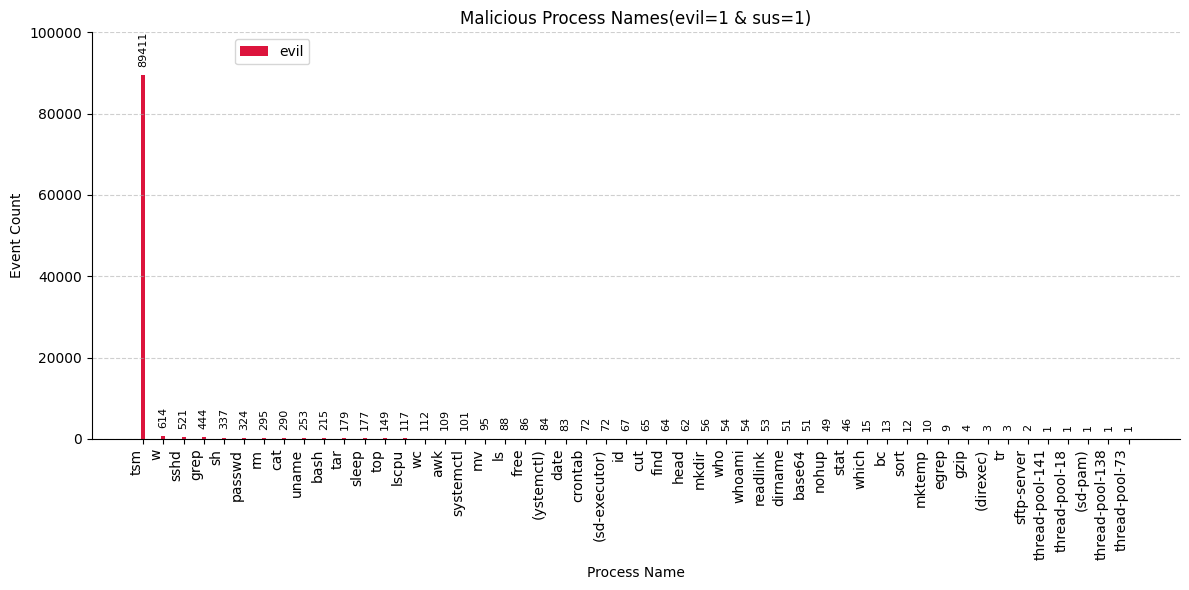

In [23]:
# Anomaly detection and Attack classsification
## 1. Malicious Process Names

plt.figure(figsize=(12, 6))
bar_width = 0.2
df_attack = df_beth[(df_beth['evil'] == 1) & (df_beth['sus'] == 1)]
attack_process_counts = df_attack['processName'].value_counts().head(50)
bars = plt.bar(attack_process_counts.index, attack_process_counts.values,
               color='crimson', width=bar_width, label='evil')

plt.ylabel("Event Count")
plt.xlabel("Process Name")
plt.title("Malicious Process Names(evil=1 & sus=1)" )
plt.legend(loc='upper left',bbox_to_anchor=(0.125, 1))
#plt.legend(title="Legend", loc='upper right')
plt.xticks(rotation=90, ha='right')
plt.ylim(0, 100000)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add count labels on top of bars, rotated vertically
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2000, f'{int(height)}',
             ha='center', va='bottom', fontsize=8, rotation=90)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()


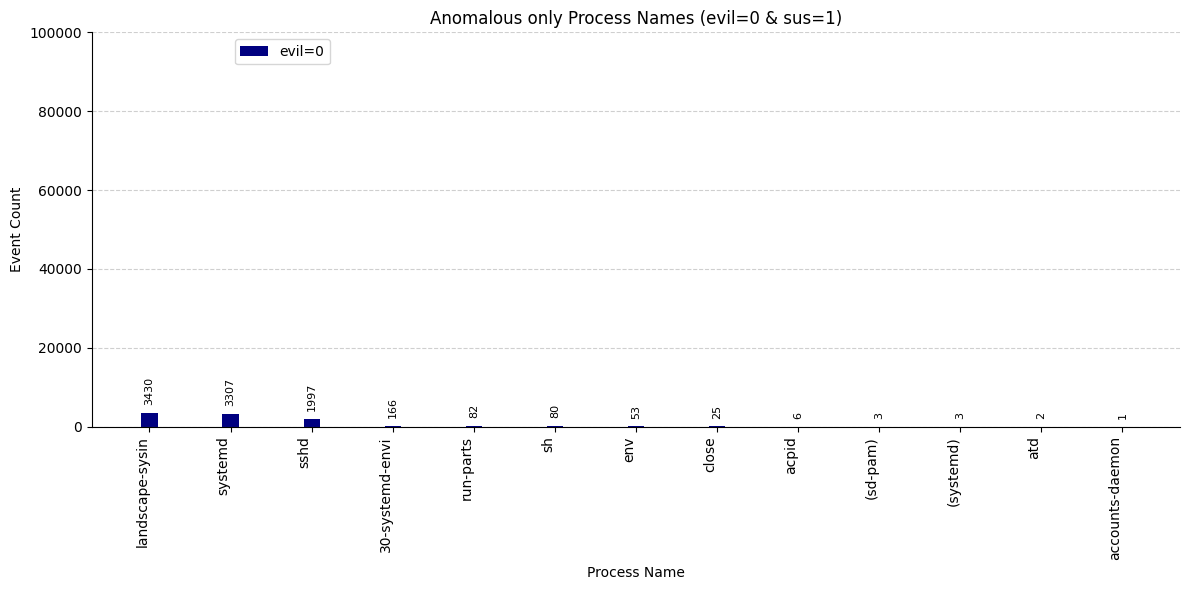

In [24]:
# Process Names with malicious patterns
# Step 1: Filter for evil=0 and sus=1
df_attack_0_1 = df_beth[(df_beth['evil'] == 0) & (df_beth['sus'] == 1)]

# Step 2: Count processName occurrences
attack_process_counts_0_1 = df_attack_0_1['processName'].value_counts()

# Optional: Limit to top N for readability
top_n = 50
attack_process_counts_0_1 = attack_process_counts_0_1.head(top_n)

# Step 3: Plot bar chart
plt.figure(figsize=(12, 6))
bar_width = 0.2
bars = plt.bar(attack_process_counts_0_1.index, attack_process_counts_0_1.values,
               color='navy', width=bar_width, label='evil=0')

plt.ylabel("Event Count")
plt.xlabel("Process Name")
plt.title("Anomalous only Process Names (evil=0 & sus=1)")
plt.legend(loc='upper left', bbox_to_anchor=(0.125, 1))
plt.xticks(rotation=90, ha='right')
plt.ylim(0, 100000)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add count labels on top of bars, rotated vertically
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2000, f'{int(height)}',
             ha='center', va='bottom', fontsize=8, rotation=90)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


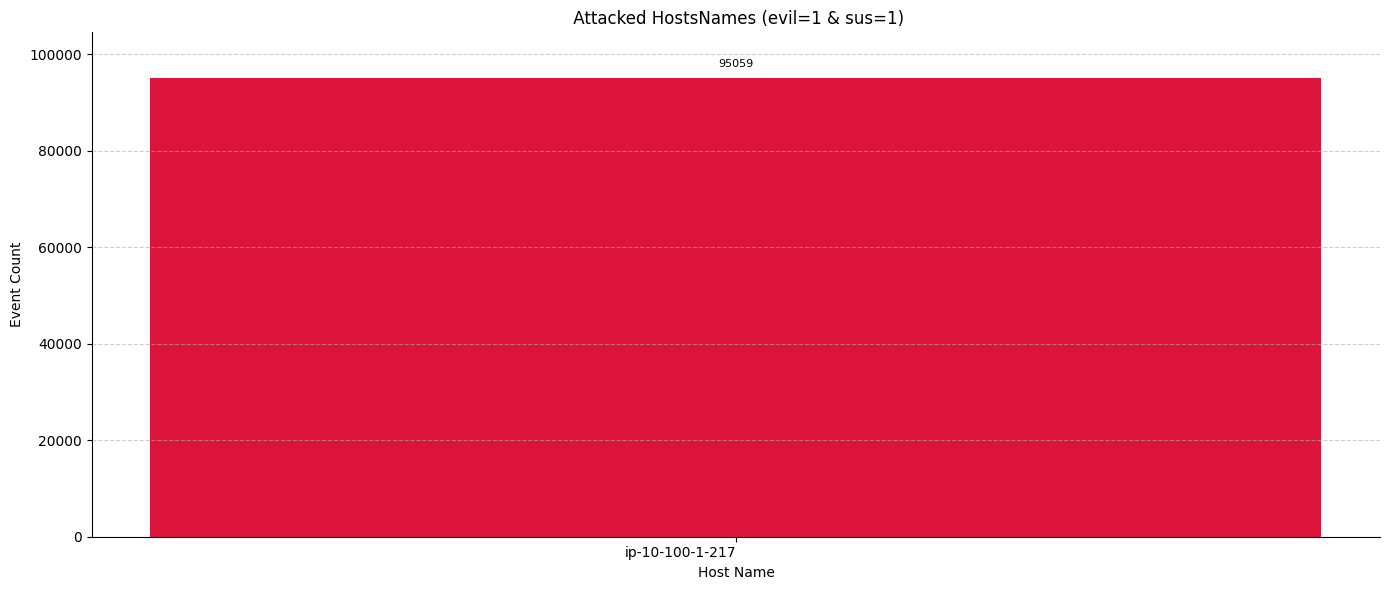

In [25]:
#  Hosts affected by  malicious events

# Step 1: Filter for evil=1 and sus=1
df_attack = df_beth[(df_beth['evil'] == 1) & (df_beth['sus'] == 1)]

# Step 2: Count occurrences of hostName
host_counts = df_attack['hostName'].value_counts()

# Optional: Limit to top N hosts
top_n = 50
host_counts = host_counts.head(top_n)

# Step 3: Plot bar chart
plt.figure(figsize=(14, 6))
bar_width = 0.6
bars = plt.bar(host_counts.index, host_counts.values, color='crimson', width=bar_width, label='evil=1 & sus=1')

plt.ylabel("Event Count")
plt.xlabel("Host Name")
plt.title(" Attacked HostsNames (evil=1 & sus=1)")
plt.xticks(rotation=0, ha='right')
plt.ylim(0, max(host_counts.values) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add count labels on top of bars, vertical rotation
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(host_counts.values)*0.02,
             f'{int(height)}', ha='center', va='bottom', fontsize=8, rotation=0)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


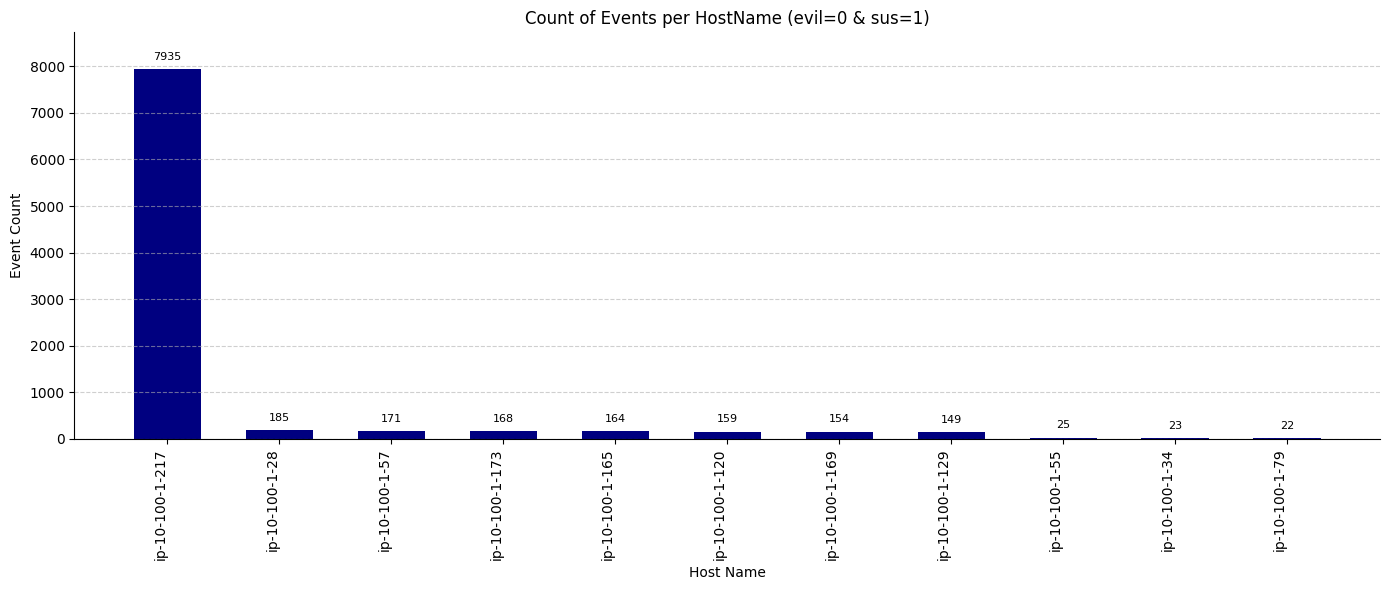

In [26]:
# Hosts with anamalous events
# Filter for evil=0 and sus=1
df_attack_0_1 = df_beth[(df_beth['evil'] == 0) & (df_beth['sus'] == 1)]

# Count occurrences of hostName
host_counts_0_1 = df_attack_0_1['hostName'].value_counts()

# Optional: Limit to top N hosts
top_n = 50
host_counts_0_1 = host_counts_0_1.head(top_n)

# Plot bar chart
plt.figure(figsize=(14, 6))
bar_width = 0.6
bars = plt.bar(host_counts_0_1.index, host_counts_0_1.values, color='navy', width=bar_width, label='evil=0 & sus=1')

plt.ylabel("Event Count")
plt.xlabel("Host Name")
plt.title("Count of Events per HostName (evil=0 & sus=1)")
plt.xticks(rotation=90, ha='right')
plt.ylim(0, max(host_counts_0_1.values) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add count labels on top of bars, rotated vertically
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(host_counts_0_1.values)*0.02,
             f'{int(height)}', ha='center', va='bottom', fontsize=8, rotation=0)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


## BETH Dataset Conclusion

The BETH dataset is suitable for host-level cybersecurity analysis. It contains process, user, host, event, and binary attack-label features that can support both attack classification and anomaly detection.

The dataset did not require major missing-value handling in this review. Duplicate checks were performed, categorical variables were encoded, and suspicious/malicious label distributions were reviewed before modeling.

The main modeling concern is class imbalance between benign and malicious activity. Because of this, later model evaluation should focus on recall, F1-score, ROC-AUC, and confusion matrices rather than accuracy alone.

The original BETH training, validation, and testing files were merged and re-split using stratified sampling so that the attack-label distribution was preserved across the new train, validation, and test sets.

# Dataset 2 : Cybersecurity Attacks Dataset
https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks

In [27]:
## 3(a) Download the dataset from kaggle
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)

100%|██████████| 5.03M/5.03M [00:01<00:00, 3.73MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/teamincribo/cyber-security-attacks/versions/31


In [28]:
import os

# List all files in the dataset directory
print(os.listdir(CSA_dataset_path))

['README.md', 'cybersecurity_attacks.csv']


In [29]:
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


In [30]:
 # 3(b) Summarize the datasets
## Display the first 05 records in chosen dataset

df_csa.head().T

,0,1,2,3,4
Timestamp,2023-05-30 06:33:58,2020-08-26 07:08:30,2022-11-13 08:23:25,2023-07-02 10:38:46,2023-07-16 13:11:07
Source IP Address,103.216.15.12,78.199.217.198,63.79.210.48,163.42.196.10,71.166.185.76
Destination IP Address,84.9.164.252,66.191.137.154,198.219.82.17,101.228.192.255,189.243.174.238
Source Port,31225,17245,16811,20018,6131
Destination Port,17616,48166,53600,32534,26646
Protocol,ICMP,ICMP,UDP,UDP,TCP
Packet Length,503,1174,306,385,1462
Packet Type,Data,Data,Control,Data,Data
Traffic Type,HTTP,HTTP,HTTP,HTTP,DNS
Payload Data,Qui natus odio asperiores nam. Optio nobis ius...,Aperiam quos modi officiis veritatis rem. Omni...,Perferendis sapiente vitae soluta. Hic delectu...,Totam maxime beatae expedita explicabo porro l...,Odit nesciunt dolorem nisi iste iusto. Animi v...


In [31]:
## Find dataset size
print("Dimension (No.of Rows, No.of Columns) of the Dataset: ",df_csa.shape)

Dimension (No.of Rows, No.of Columns) of the Dataset:  (40000, 25)


In [32]:
## Find the datatype of each feature in the dataset
df_csa.dtypes

,0
Timestamp,object
Source IP Address,object
Destination IP Address,object
Source Port,int64
Destination Port,int64
Protocol,object
Packet Length,int64
Packet Type,object
Traffic Type,object
Payload Data,object


In [33]:
## Dataset Information: Dimension, Column Names & its count, data types
df_csa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [34]:
## Dataset Description: Statistical summary for numerical columns of the dataset

df_csa.describe()

,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


In [35]:
## List the numerical and categorical columns in the dataset

csa_numeric_columns=df_csa.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_csa.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())

Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


Categorical columns in the dataset:

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']


In [36]:
## 3(c) Are there any duplicate rows ?
duplicate_rows_csa=df_csa[df_csa.duplicated()]
print(f"Duplicate rows in CSA : {len(duplicate_rows_csa)}")
#duplicate_rows_csa



Duplicate rows in CSA : 0


In [37]:
## 3(d) Are there any duplicate values in a given column

for col_csa in df_csa.columns:
    if df_csa[col_csa].duplicated().sum() > 0:
        print(f"Column {col_csa} has duplicate values.")

Column Timestamp has duplicate values.
Column Source Port has duplicate values.
Column Destination Port has duplicate values.
Column Protocol has duplicate values.
Column Packet Length has duplicate values.
Column Packet Type has duplicate values.
Column Traffic Type has duplicate values.
Column Malware Indicators has duplicate values.
Column Anomaly Scores has duplicate values.
Column Alerts/Warnings has duplicate values.
Column Attack Type has duplicate values.
Column Attack Signature has duplicate values.
Column Action Taken has duplicate values.
Column Severity Level has duplicate values.
Column User Information has duplicate values.
Column Device Information has duplicate values.
Column Network Segment has duplicate values.
Column Geo-location Data has duplicate values.
Column Proxy Information has duplicate values.
Column Firewall Logs has duplicate values.
Column IDS/IPS Alerts has duplicate values.
Column Log Source has duplicate values.


In [38]:
 ## 3(e) What are the mean, median, and mode of each column?

mean_values_csa = df_csa.mean(numeric_only=True)
print("Mean values:\n", mean_values_csa)

median_values_csa = df_csa.median(numeric_only=True)
print("\nMedian values:\n", median_values_csa)

# Mode (can have multiple values per column)
mode_values_csa = df_csa.mode(numeric_only=True).iloc[0]
print("\nMode values:\n", mode_values_csa)

Mean values:
 Source Port         32970.356450
Destination Port    33150.868650
Packet Length         781.452725
Anomaly Scores         50.113473
dtype: float64

Median values:
 Source Port         32856.000
Destination Port    33004.500
Packet Length         782.000
Anomaly Scores         50.345
dtype: float64

Mode values:
 Source Port         41341.00
Destination Port     7508.00
Packet Length        1037.00
Anomaly Scores         15.39
Name: 0, dtype: float64


In [39]:
# Check for missing or null values

missing_values_csa = df_csa.isna().sum().sort_values(ascending=False)
print("Missing values in each column:\n\n", missing_values_csa)

Missing values in each column:

 Alerts/Warnings           20067
IDS/IPS Alerts            20050
Malware Indicators        20000
Firewall Logs             19961
Proxy Information         19851
Source IP Address             0
Destination IP Address        0
Source Port                   0
Timestamp                     0
Traffic Type                  0
Packet Type                   0
Packet Length                 0
Protocol                      0
Destination Port              0
Attack Type                   0
Payload Data                  0
Anomaly Scores                0
Severity Level                0
Action Taken                  0
Attack Signature              0
User Information              0
Geo-location Data             0
Network Segment               0
Device Information            0
Log Source                    0
dtype: int64


In [40]:
df_csa.isnull().sum() / len(df_csa) * 100

,0
Timestamp,0.0000
Source IP Address,0.0000
Destination IP Address,0.0000
Source Port,0.0000
Destination Port,0.0000
Protocol,0.0000
Packet Length,0.0000
Packet Type,0.0000
Traffic Type,0.0000
Payload Data,0.0000


In [41]:
##  Drop columns with missing values and low correlation
cols_to_dropcsa = ['Timestamp','Payload Data', 'Source Port', 'Destination Port', 'IDS/IPS Alerts', 'Source IP Address','Destination IP Address','User Information', 'Device Information','Geo-location Data', 'Firewall Logs', 'Proxy Information','Log Source']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)
df_csa['Malware Indicators'].fillna('None Detected')
df_csa['Alerts/Warnings'].fillna('No Alert')
df_new_csa.info()
df_new_csa.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Protocol            40000 non-null  object 
 1   Packet Length       40000 non-null  int64  
 2   Packet Type         40000 non-null  object 
 3   Traffic Type        40000 non-null  object 
 4   Malware Indicators  20000 non-null  object 
 5   Anomaly Scores      40000 non-null  float64
 6   Alerts/Warnings     19933 non-null  object 
 7   Attack Type         40000 non-null  object 
 8   Attack Signature    40000 non-null  object 
 9   Action Taken        40000 non-null  object 
 10  Severity Level      40000 non-null  object 
 11  Network Segment     40000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 3.7+ MB


,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment
0,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Segment A
1,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Segment B
2,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Segment C
3,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Segment B
4,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Segment C


## 3(g)Encode any categorical variables  

In [42]:

# Clean column names in case of whitespace
df_new_csa.columns = df_new_csa.columns.str.strip()

# Check if 'Severity Level' column exists
if 'Severity Level' in df_new_csa.columns:
    severity_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_new_csa['Severity Level'] = df_new_csa['Severity Level'].map(severity_map)
else:
    print("ERROR: 'Severity Level' column not found.")


df_new_csa


,Protocol,Packet Length,Packet Type,Traffic Type,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,Network Segment
0,ICMP,503,Data,HTTP,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,0,Segment A
1,ICMP,1174,Data,HTTP,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,0,Segment B
2,UDP,306,Control,HTTP,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,0,Segment C
3,UDP,385,Data,HTTP,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,1,Segment B
4,TCP,1462,Data,DNS,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,0,Segment C
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,UDP,1428,Control,HTTP,IoC Detected,39.28,NaN,DDoS,Known Pattern A,Logged,1,Segment A
39996,UDP,1184,Control,HTTP,IoC Detected,27.25,NaN,DDoS,Known Pattern A,Logged,2,Segment C
39997,UDP,1043,Data,DNS,IoC Detected,31.01,NaN,DDoS,Known Pattern B,Blocked,0,Segment C
39998,UDP,483,Data,FTP,IoC Detected,97.85,Alert Triggered,Malware,Known Pattern B,Ignored,0,Segment B


# 3(h) Identify any other inconsistent data

In [43]:
csa_numeric_columns=df_csa.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(csa_numeric_columns.to_list())
print('\n')

csa_categorical_columns=df_csa.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(csa_categorical_columns.to_list())
# Check for invalid values in numeric columns (e.g., negative or zero where not expected)
print(" Invalid Values in Numeric Columns:\n")
for col in csa_numeric_columns:
    invalid_values = df_csa[df_csa[col] < 0]
    if not invalid_values.empty:
        print(f" - Column '{col}' has {len(invalid_values)} negative value(s).")

# Check for potential inconsistencies in categorical text columns
print("\n Inconsistencies in Text Columns:\n")
for col in csa_categorical_columns:
    # Strip whitespaces and compare to original
    inconsistent_entries = df_csa[col][df_csa[col].astype(str) != df_csa[col].astype(str).str.strip()]

    # Check for mixed casing as well
    unique_vals = df_csa[col].dropna().unique()
    if any(val != val.lower() for val in unique_vals) or not inconsistent_entries.empty:
        print(f" - Column '{col}' may have inconsistent formatting (spaces or casing).")
        print("   Sample unique values:", df_csa[col].dropna().unique()[:5])


Numeric columns in the dataset:

['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']


Categorical columns in the dataset:

['Timestamp', 'Source IP Address', 'Destination IP Address', 'Protocol', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']
 Invalid Values in Numeric Columns:


 Inconsistencies in Text Columns:

 - Column 'Protocol' may have inconsistent formatting (spaces or casing).
   Sample unique values: ['ICMP' 'UDP' 'TCP']
 - Column 'Packet Type' may have inconsistent formatting (spaces or casing).
   Sample unique values: ['Data' 'Control']
 - Column 'Traffic Type' may have inconsistent formatting (spaces or casing).
   Sample unique values: ['HTTP' 'DNS' 'FTP']
 - Column 'Payload Data' may have inc

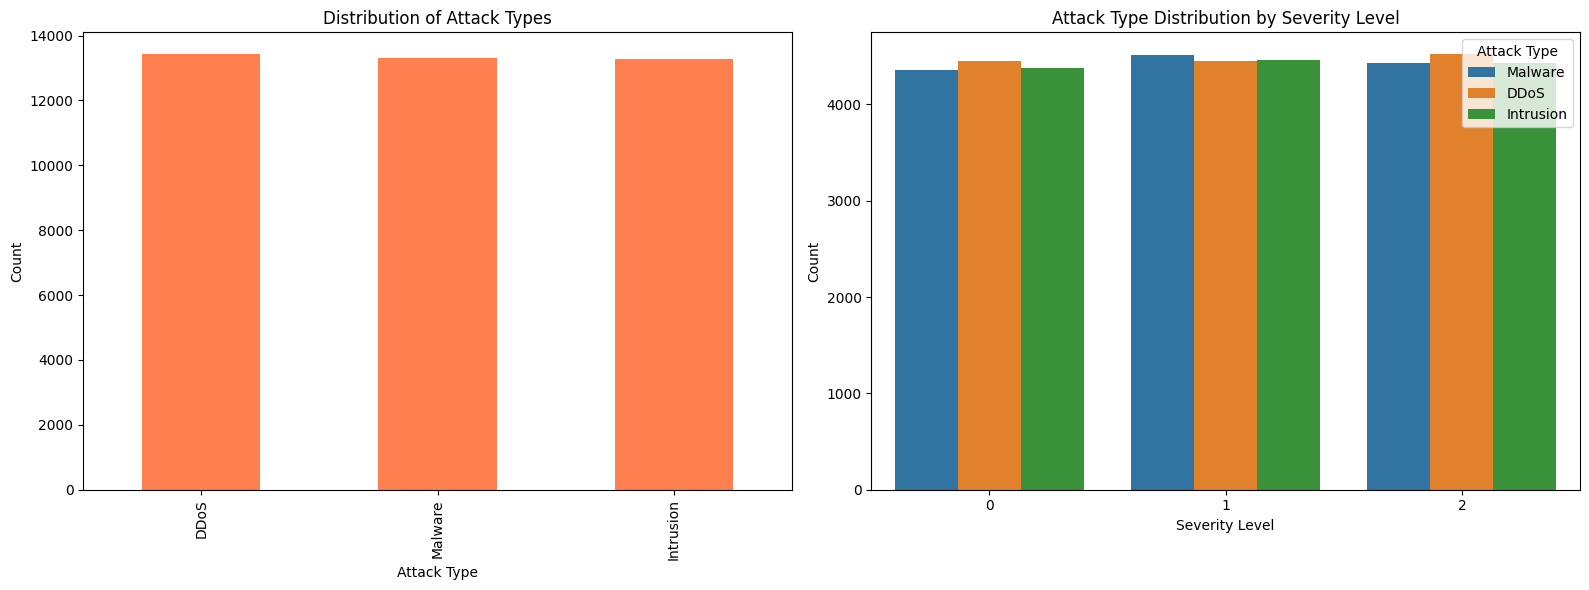

In [44]:
#Distribution of Attack Typ
# Visualization of Attack type distribution with Severity Level
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# Left plot: Distribution of Attack Types (bar plot)
df_new_csa['Attack Type'].value_counts().plot(
    kind='bar', color='coral', ax=axes[0]
)
axes[0].set_title("Distribution of Attack Types")
axes[0].set_xlabel("Attack Type")
axes[0].set_ylabel("Count")

# Right plot: Countplot of Attack Types by Severity Level
sns.countplot(
    data=df_new_csa, x="Severity Level", hue="Attack Type", ax=axes[1]
)
axes[1].set_title("Attack Type Distribution by Severity Level")
axes[1].set_xlabel("Severity Level")
axes[1].set_ylabel("Count")
axes[1].legend(title="Attack Type", loc="upper right")

plt.tight_layout()
plt.show()

In [45]:
## Is there any class imbalance?
for col in df_new_csa.columns:
    try:
        vc = df_new_csa[col].value_counts(normalize=True, dropna=False) * 100
        if not vc.empty:
            print(f"{col}: {vc.round(2).to_dict()}")
        else:
            print(f"{col}: No values to display")
    except Exception as e:
        print(f"{col}: Error - {e}")


Protocol: {'ICMP': 33.57, 'UDP': 33.25, 'TCP': 33.18}
Packet Length: {1037: 0.12, 1278: 0.11, 104: 0.11, 480: 0.11, 855: 0.11, 1361: 0.11, 777: 0.11, 346: 0.11, 459: 0.11, 1010: 0.1, 1343: 0.1, 555: 0.1, 308: 0.1, 550: 0.1, 1216: 0.1, 994: 0.1, 604: 0.1, 503: 0.1, 1421: 0.1, 199: 0.1, 433: 0.1, 1366: 0.1, 83: 0.1, 1291: 0.1, 364: 0.1, 876: 0.1, 642: 0.1, 210: 0.1, 1427: 0.1, 211: 0.1, 829: 0.1, 435: 0.1, 1000: 0.1, 434: 0.1, 1451: 0.1, 641: 0.1, 1096: 0.1, 1022: 0.1, 983: 0.1, 95: 0.1, 1039: 0.1, 1189: 0.1, 265: 0.1, 436: 0.1, 278: 0.1, 1263: 0.1, 917: 0.1, 201: 0.1, 848: 0.1, 950: 0.1, 862: 0.1, 911: 0.1, 232: 0.09, 1122: 0.09, 1210: 0.09, 131: 0.09, 245: 0.09, 328: 0.09, 1334: 0.09, 1064: 0.09, 358: 0.09, 1158: 0.09, 1284: 0.09, 1242: 0.09, 557: 0.09, 632: 0.09, 882: 0.09, 1315: 0.09, 389: 0.09, 191: 0.09, 1229: 0.09, 973: 0.09, 343: 0.09, 580: 0.09, 854: 0.09, 1463: 0.09, 1181: 0.09, 1331: 0.09, 209: 0.09, 1080: 0.09, 303: 0.09, 912: 0.09, 1048: 0.09, 676: 0.09, 281: 0.09, 548: 0.09

No significant class imbalance detected in any of the categories. All categories have roughly evenly distributed classes.

## Cybersecurity Attacks Dataset Conclusion

The Cybersecurity Attacks dataset is useful for basic attack-type exploration and pipeline testing, but it should be interpreted carefully.

The dataset contains several fields with high missing-value percentages or limited modeling value, including free-text fields, IP address fields, device information, firewall logs, proxy information, and log-source identifiers. These fields should be dropped, cleaned, or transformed depending on the modeling goal.

Categorical variables such as attack type, severity level, protocol, traffic type, action taken, and network segment require encoding before machine learning.

Although some category counts may appear balanced in simple frequency checks, this dataset still has important limitations. In the broader capstone modeling work, rare-class detection was a major issue, showing that high overall accuracy can be misleading when minority attack behavior is not detected.

Overall, this dataset is best used as a supplementary cybersecurity dataset rather than the strongest source for final model performance.

# Dataset 3: UNSW-NB15 Intrusion Detection Dataset
https://doi.org/10.34740/KAGGLE/DSV/9350725


In [46]:
# 3(a) Download the dataset

#!pip install fastparquet pyarrow
#!pip install --upgrade pip
path = kagglehub.dataset_download("dhoogla/unswnb15")

# Load the training and testing  set parquet file into DataFrame
df_unsw = pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


Using Colab cache for faster access to the 'unswnb15' dataset.


In [47]:
# 3(b) Summarize the datasets

## Display the first 05 records in chosen dataset
df_unsw.head()


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [48]:
df_test_unsw.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,...,0,0,2,1,0,0,0,0,Normal,0


In [49]:
## Find dataset size

print("Dimension (No.of Rows, No.of Columns) of the Dataset: ",df_unsw.shape)
print("Dimension (No.of Rows, No.of Columns) of the Dataset: ",df_test_unsw.shape)

Dimension (No.of Rows, No.of Columns) of the Dataset:  (175341, 36)
Dimension (No.of Rows, No.of Columns) of the Dataset:  (82332, 36)


In [50]:
## Find the datatype of each feature in the dataset
print("training dataset datatypes:",df_unsw.dtypes)
print("testing dataset datatypes :",df_unsw.dtypes)

training dataset datatypes: dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_

In [51]:
## Dataset Information: Dimension, Column Names & its count, data types

print("training dataset info:",df_unsw.info())
print("testing dataset info:",df_test_unsw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit               175341 non-null

In [52]:
## Dataset Description: Statistical summary for numerical columns of the dataset
df_unsw.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,...,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,...,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712055e+05,4.953000,6.948010,...,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.483313,136.887597,110.258271,1.747656e+05,1.436542e+05,165417.671875,1.883701e+08,2.423637e+06,66.005059,52.732999,...,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,...,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,...,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,...,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


In [53]:
## List all numerical and categorical columns
unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns.to_list())
print(f"Count of numeric columns: {len(unsw_numeric_columns)}")

print('\n')

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns.to_list())
print(f"Count of categorical columns: {len(unsw_categorical_columns)}")

Numeric columns in the dataset:

['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'label']
Count of numeric columns: 32


Categorical columns in the dataset:

['proto', 'service', 'state', 'attack_cat']
Count of categorical columns: 4


In [54]:

## 3(c) Are there any duplicate rows ?
duplicate_rows_unsw=df_unsw[df_unsw.duplicated()]
print(f"Duplicate rows in CSA : {len(duplicate_rows_unsw)}")
#duplicate_rows_csa


Duplicate rows in CSA : 78519


In [55]:
duplicate_count = df_unsw.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# If duplicates exist, display them
if duplicate_count > 0:
    #print("\nDuplicate rows:")
    #print(df_unsw[df_unsw.duplicated()])

    # Option 1: Remove duplicates, keeping the first occurrence
    df_unsw_no_duplicates = df_unsw.drop_duplicates(keep='first')
    print(f"\nShape after removing duplicates: {df_unsw_no_duplicates.shape}")

    # Option 2: Save the cleaned dataset (if needed)
    #df_unsw_no_duplicates.to_parquet('UNSW_NB15_training-set_cleaned.parquet')

else:
    print("\nNo duplicates found in the dataset.")

Number of duplicate rows: 78519

Shape after removing duplicates: (96822, 36)


In [56]:
## 3(d) Are there any duplicate values in a given column (when this would be inappropriate?)
for col_unsw in df_unsw.columns:
    if df_unsw[col_unsw].duplicated().sum() > 0:
        print(f"Column {col_unsw} has duplicate values.")

Column dur has duplicate values.
Column proto has duplicate values.
Column service has duplicate values.
Column state has duplicate values.
Column spkts has duplicate values.
Column dpkts has duplicate values.
Column sbytes has duplicate values.
Column dbytes has duplicate values.
Column rate has duplicate values.
Column sload has duplicate values.
Column dload has duplicate values.
Column sloss has duplicate values.
Column dloss has duplicate values.
Column sinpkt has duplicate values.
Column dinpkt has duplicate values.
Column sjit has duplicate values.
Column djit has duplicate values.
Column swin has duplicate values.
Column stcpb has duplicate values.
Column dtcpb has duplicate values.
Column dwin has duplicate values.
Column tcprtt has duplicate values.
Column synack has duplicate values.
Column ackdat has duplicate values.
Column smean has duplicate values.
Column dmean has duplicate values.
Column trans_depth has duplicate values.
Column response_body_len has duplicate values.


In [57]:

 ## 3(e) What are the mean, median, and mode of each column?


mean_values_unsw = df_unsw.mean(numeric_only=True)
print("Mean values:\n", mean_values_unsw)

median_values_unsw = df_unsw.median(numeric_only=True)
print("\nMedian values:\n", median_values_unsw)

# Mode (can have multiple values per column)
mode_values_unsw = df_unsw.mode(numeric_only=True).iloc[0]
print("\nMode values:\n", mode_values_unsw)

Mean values:
 dur                  1.359389e+00
spkts                2.029866e+01
dpkts                1.896959e+01
sbytes               8.844844e+03
dbytes               1.492892e+04
rate                 9.540618e+04
sload                7.345403e+07
dload                6.712055e+05
sloss                4.953000e+00
dloss                6.948010e+00
sinpkt               9.859768e+02
dinpkt               8.821630e+01
sjit                 4.976255e+03
djit                 6.043538e+02
swin                 1.162573e+02
stcpb                9.692504e+08
dtcpb                9.688770e+08
dwin                 1.150136e+02
tcprtt               4.139564e-02
synack               2.102045e-02
ackdat               2.037519e-02
smean                1.367518e+02
dmean                1.241734e+02
trans_depth          1.059821e-01
response_body_len    2.144292e+03
ct_src_dport_ltm     5.383538e+00
ct_dst_sport_ltm     4.206255e+00
is_ftp_login         1.494802e-02
ct_ftp_cmd           1.494802e-02


In [58]:
## 3(f). Are there any missing or null values?
# Check for missing or null values
missing_values_unsw = df_unsw.isna().sum().sort_values(ascending=False)
print("Missing values in each column:\n\n", missing_values_unsw)

Missing values in each column:

 dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64


In [59]:
## 3(g)Encode any categorical variables (e.g. with one-hot encoding.)
from sklearn.preprocessing import LabelEncoder
convert_columns = list(df_unsw.select_dtypes(include=['category','object']).columns)
convert_columns
label_encoder = LabelEncoder()

# convert
for column in convert_columns:
    df_unsw[column] = label_encoder.fit_transform(df_unsw[column])
df_unsw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                175341 non-null  float32
 1   proto              175341 non-null  int64  
 2   service            175341 non-null  int64  
 3   state              175341 non-null  int64  
 4   spkts              175341 non-null  int16  
 5   dpkts              175341 non-null  int16  
 6   sbytes             175341 non-null  int32  
 7   dbytes             175341 non-null  int32  
 8   rate               175341 non-null  float32
 9   sload              175341 non-null  float32
 10  dload              175341 non-null  float32
 11  sloss              175341 non-null  int16  
 12  dloss              175341 non-null  int16  
 13  sinpkt             175341 non-null  float32
 14  dinpkt             175341 non-null  float32
 15  sjit               175341 non-null  float32
 16  dj

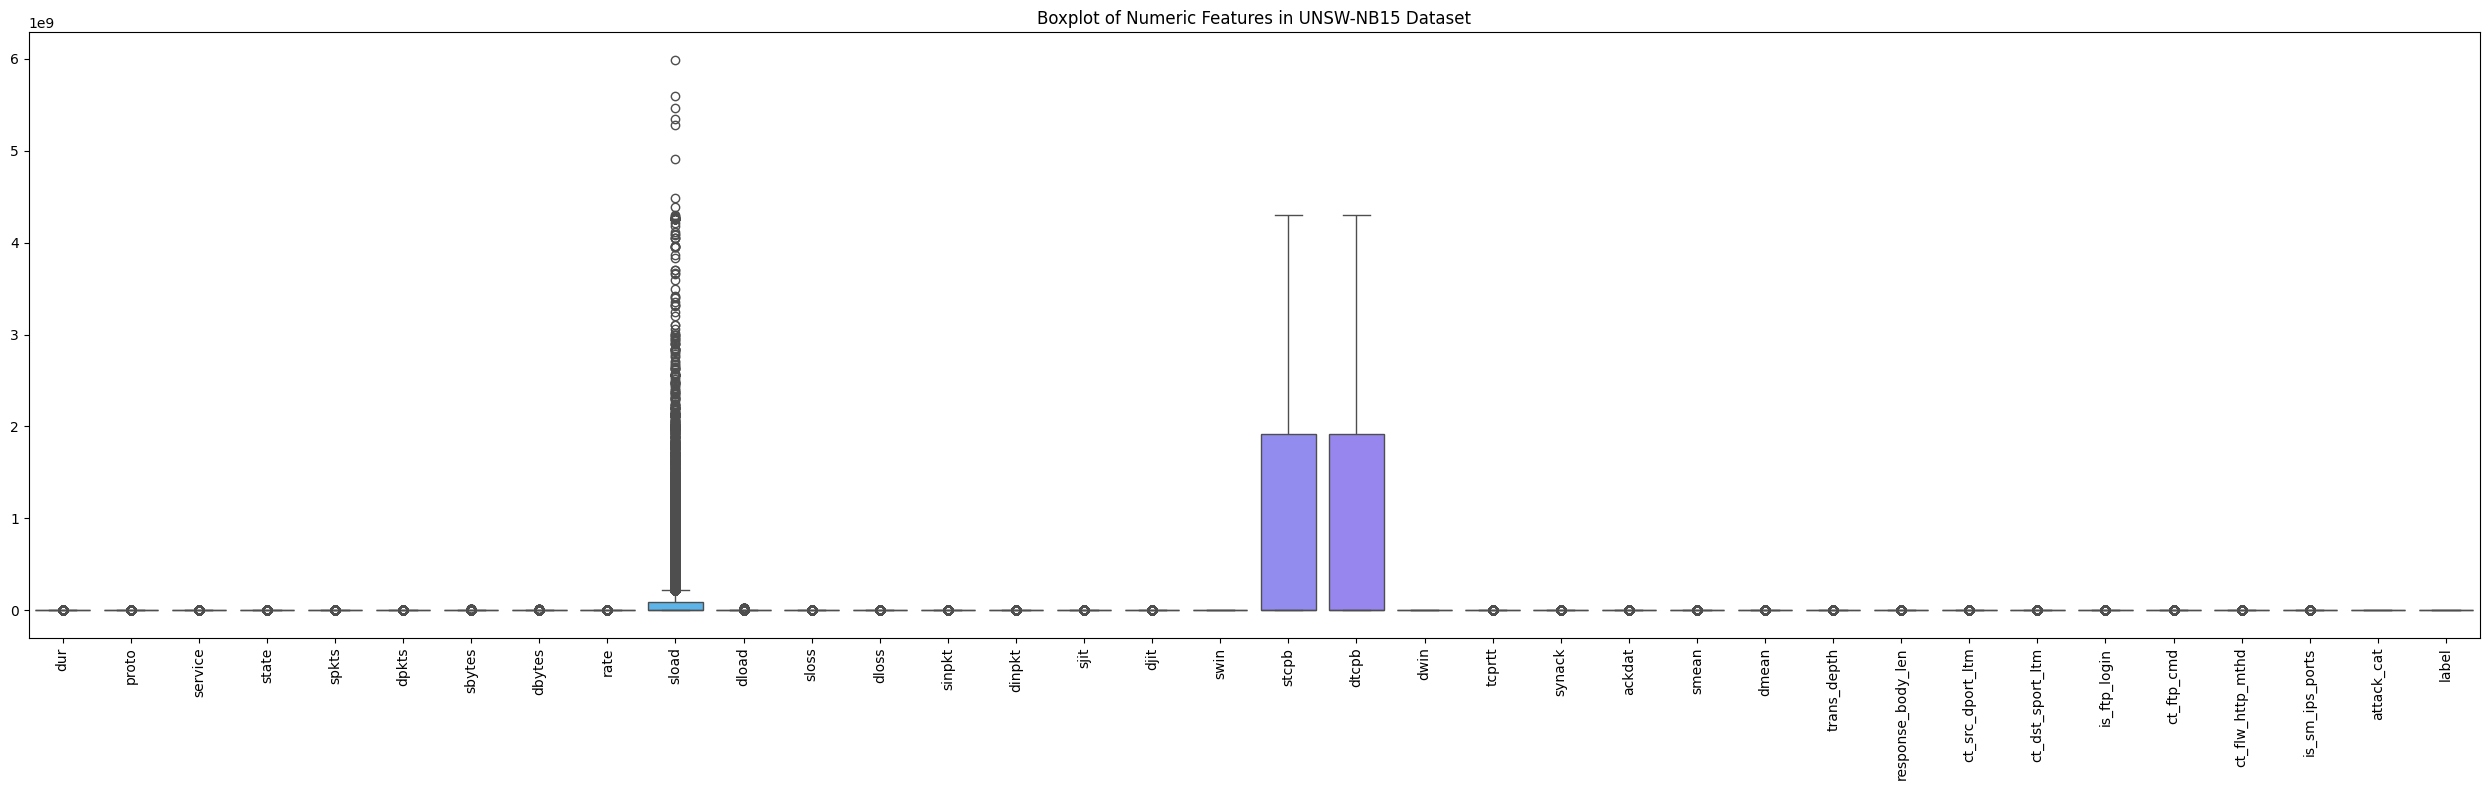

In [60]:
## Check  for Outlier
# Select numeric columns
numeric_columns = df_unsw.select_dtypes(include='number').columns

# Create boxplot for numeric columns
plt.figure(figsize=(25, 8))
outliers = sns.boxplot(data=df_unsw[numeric_columns], palette='cool')
plt.xticks(ticks=range(len(numeric_columns)), labels=numeric_columns, rotation=90)
plt.title('Boxplot of Numeric Features in UNSW-NB15 Dataset')
plt.tight_layout()

# Save the plot
#plt.savefig('boxplot_numeric_features.png')
plt.show()

Class distribution (normal vs attack) in Training Data:
label
1    119341
0     56000
Name: count, dtype: int64


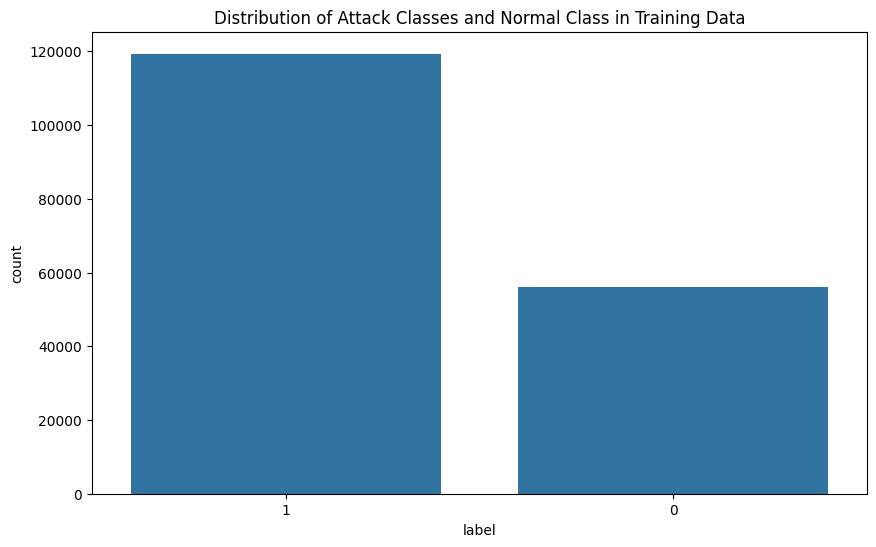

In [61]:
# Examine the Distribution of Attack Classes and Normal Class
# Assuming the target label column is named 'label' and contains both normal and attack class info
if 'label' in df_unsw.columns:
    print("Class distribution (normal vs attack) in Training Data:")
    print(df_unsw['label'].value_counts())

    # Plot the distribution of classes
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_unsw, x='label', order=df_unsw['label'].value_counts().index )
    plt.title('Distribution of Attack Classes and Normal Class in Training Data')
    plt.show()


#### Is there any class imbalance?
The dataset has class imbalance with 119341 instances of label 1 (attack) versus 56000 instances of label 0 (normal), a ratio of approximately 2.13:1. Techniques like oversampling, undersampling, or using class weights in models can address this imbalance.

In [62]:
# Check class distribution in the training set
print("Class distribution in Training Data ('label' column):")
print(df_unsw['label'].value_counts())

# Check attack categories distribution in the training set
print("\nAttack categories distribution in Training Data ('attack_cat' column):")
print(df_unsw['attack_cat'].value_counts())

Class distribution in Training Data ('label' column):
label
1    119341
0     56000
Name: count, dtype: int64

Attack categories distribution in Training Data ('attack_cat' column):
attack_cat
6    56000
5    40000
3    33393
4    18184
2    12264
7    10491
0     2000
1     1746
8     1133
9      130
Name: count, dtype: int64


## UNSW-NB15 Dataset Conclusion

The UNSW-NB15 dataset is suitable for network intrusion detection analysis. It provides network-flow features and binary attack labels that can support supervised classification.

The dataset required review of duplicate records, missing values, categorical variables, feature distributions, outliers, and class balance before modeling. Categorical features such as protocol, service, state, and attack category need to be encoded before machine learning.

The binary target shows class imbalance between attack and normal traffic, so model evaluation should not rely only on accuracy. Recall, precision, F1-score, ROC-AUC, and confusion matrices are more useful for judging intrusion detection performance.

This dataset is one of the stronger sources for network-level threat detection in the project, although its age and attack-profile limitations should be considered before applying results to modern production environments.

### Overall Data Quality Conclusion

All three datasets are usable for academic cybersecurity machine learning analysis, but each dataset serves a different purpose.

BETH is strongest for host-level behavior analysis because it includes process, user, host, and event-level activity from honeypot logs.

UNSW-NB15 is strongest for network-level intrusion detection because it includes network-flow features and attack labels.

The Cybersecurity Attacks dataset is useful for exploratory analysis and pipeline testing, but it should be interpreted more cautiously because of missing values, synthetic patterns, and rare-class detection concerns.

Across all datasets, cybersecurity model evaluation should focus on more than accuracy. Recall, F1-score, ROC-AUC, confusion matrices, and class-specific performance are important because attacks can be rare and costly to miss.

These preprocessing findings helped guide later model selection, feature engineering, and evaluation in the capstone project.